In [1]:
pip install nltk textblob

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [11]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/new/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [13]:
sia.polarity_scores("Apple stock rises after strong earnings")

{'neg': 0.0, 'neu': 0.602, 'pos': 0.398, 'compound': 0.5106}

In [14]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [16]:
news_df.head ()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [17]:
news_df.tail ()

,Unnamed: 0,headline,url,publisher,date,stock
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX
1407327,1413848,China Zenix Auto International Opens For Tradi...,https://www.benzinga.com/news/ipos/11/05/10789...,Allie Wickman,2011-05-12 00:00:00,ZX


In [18]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [20]:
news_df["date"] = pd.to_datetime(news_df["date"], format='mixed', utc=True)

In [21]:
news_df.head ()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [22]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype              
---  ------      --------------    -----              
 0   Unnamed: 0  1407328 non-null  int64              
 1   headline    1407328 non-null  object             
 2   url         1407328 non-null  object             
 3   publisher   1407328 non-null  object             
 4   date        1407328 non-null  datetime64[ns, UTC]
 5   stock       1407328 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(1), object(4)
memory usage: 64.4+ MB


In [23]:
news_df["date_only"] = news_df["date"].dt.date

In [24]:
sia = SentimentIntensityAnalyzer()

In [25]:
news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

In [27]:
 stock_df = pd.read_csv("../data/raw/DATA/AAPL.csv")

In [29]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df["date_only"] = stock_df["Date"].dt.date

In [30]:
stock_df["daily_return"] = stock_df["Close"].pct_change() * 100

In [31]:
daily_sentiment = news_df.groupby("date_only")["sentiment_score"].mean().reset_index()

In [32]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[["date_only", "daily_return"]],
    on="date_only",
    how="inner"
)

In [33]:
correlation = merged_df["sentiment_score"].corr(
    merged_df["daily_return"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.14478111403119998


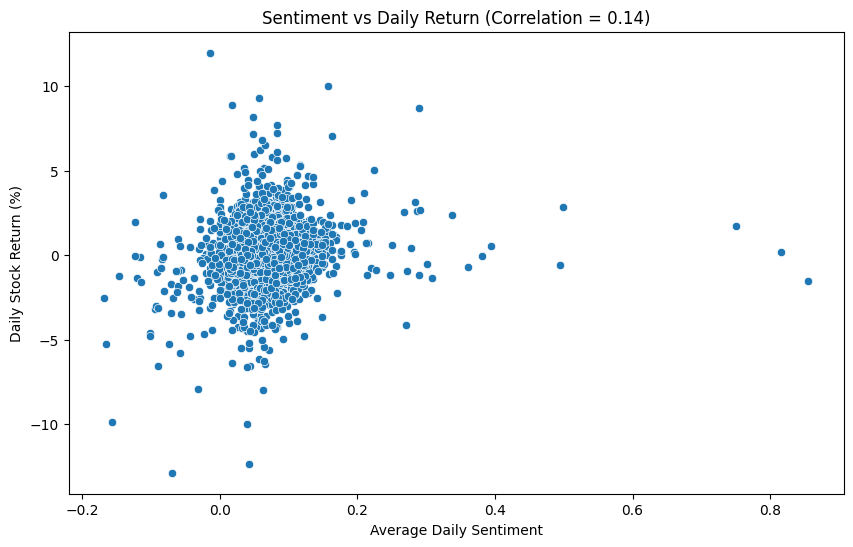

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="sentiment_score",
    y="daily_return"
)

plt.title(f"Sentiment vs Daily Return (Correlation = {correlation:.2f})")

plt.xlabel("Average Daily Sentiment")

plt.ylabel("Daily Stock Return (%)")

plt.show()

In [35]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged_df["sentiment_category"] = merged_df["sentiment_score"].apply(classify_sentiment)

In [36]:
category_returns = merged_df.groupby(
    "sentiment_category"
)["daily_return"].mean()

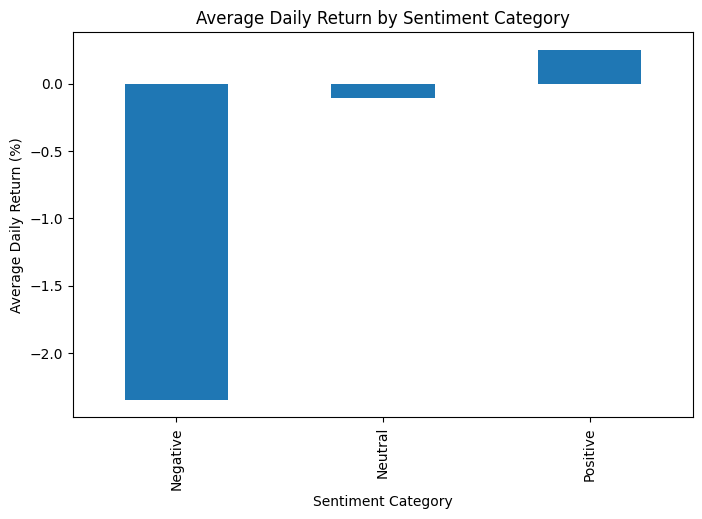

In [37]:
category_returns.plot(kind="bar", figsize=(8,5))

plt.title("Average Daily Return by Sentiment Category")

plt.xlabel("Sentiment Category")

plt.ylabel("Average Daily Return (%)")

plt.show()